In [1]:
import joblib
import numpy as np

# ******** I级CV识别模型 ******** 
# 加载UMAP模型
reducer = joblib.load('final_umap_reducer_20251208.37_thr0.25_rec1.000_f1984.joblib')
# 加载随机森林分类器模型
clf = joblib.load('final_random_forest_20251208.37_thr0.25_rec1.000_f1984.joblib')
# 使用新数据进行预测的函数保持不变
def predict_new_data(new_X):
    new_embedding = reducer.transform(new_X)
    return clf.predict_proba(new_embedding)[:, 1]
    
def load_contamination_model(save_name):
    """
    加载污染检测模型
    参数:
        save_name: 模型保存时使用的后缀名
    返回:
        tuple: (reducer, model, threshold)
    """
    # 加载模型组件
    reducer = joblib.load(f'contamination_umap_reducer_{save_name}.joblib')
    model = joblib.load(f'contamination_random_forest_{save_name}.joblib')
    threshold = np.load(f'contamination_threshold_{save_name}.npy')
    print(f'load:')
    print(f'contamination_umap_reducer_{save_name}.joblib')
    print(f'contamination_random_forest_{save_name}.joblib')
    print(f'contamination_threshold_{save_name}.npy')
    return reducer, model, threshold

In [2]:
import numpy as np
import numba
import umap
import sklearn
import joblib

print(f"NumPy: {np.__version__}")
print(f"Numba: {numba.__version__}")
print(f"UMAP: {umap.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")


NumPy: 1.26.4
Numba: 0.59.0
UMAP: 0.5.6
Scikit-learn: 1.2.2
Joblib: 1.4.2


In [3]:
# ******** II级污染识别模型 ******** 
# 简化版预测函数（仅输出是否污染）
def predict_new_data_contamination(new_spectra):
    """
    简化的预测函数，只输出是否污染
    
    参数:
        new_spectra: numpy数组，形状为(n_samples, 1458)
        save_name: 模型保存时使用的后缀名
    
    返回:
        numpy数组: 每个样本的预测结果（1=污染，0=目标）
    """
    #print('II级模型阈值：', threshold)
    new_umap = reducer2.transform(new_spectra)
    contamination_probs = model2.predict_proba(new_umap)[:, 1]
    predictions = (contamination_probs >= threshold2).astype(int)
    # 输出结果
    print(f"预测结果（1=污染，0=目标）:")
    print(predictions)
    # # 输出详细解释
    # for i, (prob, pred) in enumerate(zip(contamination_probs, predictions)):
    #     status = "污染" if pred == 1 else "目标"
    #     print(f"样本{i+1}: 概率={prob:.4f}, 判断={pred} ({status})")
    
    return predictions

# contamination_umap_reducer_20251211IIv3b.1
mymodel = '20251211IIv3b.1'
reducer2, model2, threshold2 = load_contamination_model(save_name=mymodel)

load:
contamination_umap_reducer_20251211IIv3b.1.joblib
contamination_random_forest_20251211IIv3b.1.joblib
contamination_threshold_20251211IIv3b.1.npy


In [7]:
# 导入需要的模块
import numpy as np
import os
import matplotlib.pyplot as plt
from astropy.table import Table
import wget
import csv
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.stats import sigma_clip
from scipy.signal import medfilt
from scipy.fftpack import fft,ifft
def fft_smooth(flux, threashold=900, ifplot=False):
    # 输入：光谱流量数组，裁切高频的阈值，是否绘制效果图片
    # fft平滑，裁切频率大于设置值的信号，返回平滑后的流量数组
    
    # FFT
    func_fft = fft(flux) # 快速傅里叶变换
    func_amp = np.abs(func_fft) # 取模
    frq = np.arange(len(flux))
    
    if ifplot:
        #绘制频域图像
        f = plt.figure(2, figsize=(5,3), dpi=100)
        func_amp = func_amp / max(func_amp) #振幅归一化
        plt.plot(frq, func_amp, linewidth=0.5)
        plt.xlabel("frequency")
        plt.ylim(-0.02,0.2)
        plt.title("FFT")
        plt.clf()
        plt.close(f)
        plt.close('all')
    # ---裁切高频---
    f_cut_threshold = threashold
    cut_center = len(flux) / 2
    f_cut_range = cut_center - f_cut_threshold
    cut_center_left = int(cut_center - f_cut_range)
    cut_center_right = int(cut_center + f_cut_range)
    func_fft[cut_center_left:cut_center_right] = 0

    if ifplot:        
        #绘制频域图像
        func_amp = np.abs(func_fft) #取模
        frq = np.arange(len(flux))
        f = plt.figure(2, figsize=(5,3), dpi=100)
        func_amp = func_amp/max(func_amp) #振幅归一化
        plt.plot(frq, func_amp, linewidth=0.5)
        plt.ylim(-0.02,0.2)
        plt.xlabel("frequency")
        plt.title(f"FFT_cut threashold={threashold}")
        plt.clf()
        plt.close(f)
        plt.close('all')
        
    #逆傅里叶变换
    func_ifft = ifft(func_fft)
    flux_ifft = func_ifft.real
    return flux_ifft
    
def flux_clip(wave, flux, sigma_hi=3.9, sigma_lo=3.6):
    # 输入：波长和流量列表，裁切上下限(默认3.9，3.6)
    # 功能：裁切流量范围，超出范围的置为np.nan，返回修改后的波长和流量
    wave = np.array(wave)
    flux = np.array(flux)
    
    center = np.nanmedian(flux) # 获取中位流量
    std = np.nanstd(flux) # 获取流量标准差
    
    cut = (flux < center+sigma_hi*std) & (flux > center-sigma_lo*std) # 筛选
    wave[~cut] = np.nan 
    flux[~cut] = np.nan
    return wave, flux
    
def median_filter(flux, n=3):
    return medfilt(flux, n)


def process_array(arr, n, k):
    original = np.array(arr)
    processed = original.copy()
    length = len(original)
    
    for i in range(length):
        # 确定窗口范围
        left = max(0, i - n)
        right = min(length - 1, i + n)
        window = original[left : right + 1]
        #print(window)
        # 计算均值和标准差（总体标准差）
        mu = np.median(window)
        sigma = np.std(window, ddof=0)
        
        if sigma == 0:
            continue  # 标准差为零则跳过
        
        # 检查当前点是否超过k倍sigma
        current_val = original[i]
        if abs(current_val - mu) > k * sigma:
            # 生成mask判断哪些点超过阈值
            mask = np.abs(window - mu) > k * sigma
            total_outliers = np.sum(mask)
            
            # 当前点在窗口中的位置
            pos_in_window = i - left
            p1 = pos_in_window-1
            p2 = pos_in_window+1
            if total_outliers <= 2 and mask[pos_in_window]:
                if len(window) > 2*n:
                    # 计算中位数并替换
                    median = np.median(window)
                    processed[i] = median
                    if mask[p1]:
                        processed[i-1] = median
                    if mask[p2]:
                        processed[i+1] = median
                
    return processed.tolist()

def bin_and_average(arr, k):
    """
    将数组arr每k个元素合并为一个点，该点值为这k个元素的平均值。
    
    参数:
        arr (list or numpy.ndarray): 输入的一维数组。
        k (int): 每k个元素合并为一个点。
        
    返回:
        list: 合并后的数组，每个元素是原数组中每k个元素的平均值。
    """
    # 确保输入数组是一维的numpy数组或列表，这里假设输入为列表或者numpy数组
    if not isinstance(arr, (list, np.ndarray)):
        raise TypeError("Input arr must be a list or numpy ndarray.")
    
    # 如果输入的是列表，转换为numpy数组方便处理
    arr = np.array(arr) if isinstance(arr, list) else arr
    
    # 检查k是否有效
    if k <= 0:
        raise ValueError("Parameter k must be positive.")
    
    # 计算新的数组长度
    new_len = len(arr) // k
    
    # 使用列表推导式生成新数组
    binned_means = [arr[i*k:(i+1)*k].mean() for i in range(new_len)]
    
    return binned_means

def replace_anomalies_with_median(arr, n, sigma=2.):
    """
    对于给定的数组arr，找到临近长度为2*n+1区间内被sigma_clip认为是异常且值为0的点，
    并将其替换为对应区间的中位数。
    
    :param arr: 输入的一维numpy数组
    :param n: 区间半径，即在目标点两侧各取n个元素形成的区间
    :param sigma: sigma_clip函数使用的标准差倍数，默认为3
    :return: 替换后的数组
    """
    # 创建一个副本以避免直接修改原数组
    result = np.copy(arr)
    length = len(arr)

    for i in range(length):
        # 计算当前点的左右边界，注意处理数组边缘情况
        left = max(0, i - n)
        right = min(length, i + n + 1) # +1因为切片是左闭右开
        
        # 获取当前区间
        interval = arr[left:right]
        if len(interval) >= 2*n:
            #print(' ',interval)
            # 使用sigma_clip找出异常值的位置
            filtered_data = sigma_clip(interval, maxiters=3, sigma=sigma, masked=True)
            #print('*',filtered_data)
            # 遍历过滤后的数据，寻找值为0且被认为是异常的点
            for j, is_masked in enumerate(filtered_data.mask):
                if is_masked and interval[j] == 0:
                    # 计算区间中位数并替换
                    arr2 = []
                    for ll in interval:
                        if ll != 0:
                            arr2.append(ll) 
                    if len(arr2)>n:
                        #print('c',arr2)
                        median_value = np.mean(arr2)
                        result[left + j] = median_value
                
    return result

from scipy.optimize import curve_fit
# 定义一个二次多项式函数
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# 拟合并归一化光谱
def normalize_spectrum(wavelengths, fluxes, nwave,nflux):
    # 使用curve_fit进行二次多项式拟合
    try:
        params, covariance = curve_fit(quadratic, wavelengths, fluxes)
        
    # 计算拟合的连续谱
        fitted_continuum = quadratic(nwave, *params)
    except:
        fitted_continuum = np.ones_like(nflux)
    # 归一化：将原始流量除以连续谱模型
    normalized_fluxes = nflux / fitted_continuum
    
    return nwave, normalized_fluxes, fitted_continuum

#import numpy as np
from scipy.interpolate import interp1d

def linear_interpolation(arrayx, arrayy, newx):
    """
    使用线性插值计算新网格点的值
    
    参数:
    arrayx (array-like): 已知数据点的 x 坐标
    arrayy (array-like): 已知数据点的 y 坐标
    newx (array-like): 需要插值的新 x 坐标网格
    
    返回:
    newy (ndarray): 新网格点对应的插值结果
    
    注意:
    - 自动处理输入数组的排序
    - 对超出原始范围的点进行外推
    """
    # 确保输入为 NumPy 数组
    x = np.asarray(arrayx)
    y = np.asarray(arrayy)
    newx = np.asarray(newx)
    
    # 检查数据有效性
    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("arrayx 和 arrayy 必须是一维数组")
    if len(x) != len(y):
        raise ValueError("arrayx 和 arrayy 长度必须相同")
    if len(x) < 2:
        raise ValueError("至少需要两个点进行插值")
    
    # 创建线性插值函数 (自动排序 + 外推)
    f = interp1d(
        x, y, 
        kind='linear',      # 线性插值
        assume_sorted=False,  # 自动排序输入数据
        fill_value='extrapolate'  # 允许外推
    )
    
    # 计算新点的插值结果
    newy = f(newx)
    return newy

def fill_nan_with_neighbors(stdfx):
    filled = stdfx.copy()
    n = len(stdfx)
    
    for i in range(n):
        if np.isnan(stdfx[i]):
            left = i - 1
            right = i + 1
            
            # 向左找第一个非nan
            while left >= 0 and np.isnan(stdfx[left]):
                left -= 1
                
            # 向右找第一个非nan
            while right < n and np.isnan(stdfx[right]):
                right += 1
            
            # 根据左右是否有有效值进行填充
            if left >= 0 and right < n:
                filled[i] = (stdfx[left] + stdfx[right]) / 2
            elif left >= 0:
                filled[i] = stdfx[left]
            elif right < n:
                filled[i] = stdfx[right]
            else:
                # 整个数组都是nan的情况
                pass
    
    return filled


import warnings
warnings.filterwarnings('ignore')

import subprocess
# 下载光谱
def download_lamost_DR11(obsid, path):
    # 输入：obsid和保存路径(仅路径)
    # 函数下载lamost光谱到指定路径，格式为.fits.gz
    # 返回下载的url和下载的fits文件
    url = r'http://www.lamost.org/dr11/v1.0/spectrum/fits/'+str(obsid)
    save_name = path + 'DR11LRS_' + str(obsid) + '.fits.gz'
    # 若之前存在文件，则不动
    if not os.path.exists(save_name):
        try:
            result = subprocess.run(["wget", "-nc", "-O", save_name, url],
                                    check=False,          # 不自动抛异常，便于手动处理
                                    stdout=subprocess.DEVNULL,   # 可选：隐藏输出
                                    stderr=subprocess.DEVNULL)
            if result.returncode == 0:
                fitsfile = save_name
                #print("下载成功！")
            else:
                print(f"{obsid} 下载失败，wget 退出码: {result.returncode}")
                fitsfile = False
        except Exception as e:
            print(f"{obsid} 执行出错: {e}")
            fitsfile = False
    else:
        print(save_name,'already exists.')
        fitsfile = save_name
    return (url, fitsfile)
    
# 读取光谱
def read_sp(sp_file):
    with fits.open(sp_file) as fitsfile:# 读入fits
        data=fitsfile[1].data[0]
        wave=data[2]
        flux=data[0]
    return wave,flux
    
# 处理光谱
def process_sp(w,f):
    # 将连续谱与谱线区间相乘
    stdwv = np.load('wavef_standard.npy')
    
    wave,flux = w,f # 复制波长、流量
    flux1 = process_array(flux, n=7, k=2.8) # 去宇宙线
    
    #print(len(flux1))
    flux20 = replace_anomalies_with_median(flux1, n=4, sigma=2.0) # 去异常0值
    #print(len(flux20))
    
    flux2=flux20[~np.isinf(flux20)] # 剔除inf
    wave =wave[~np.isinf(flux20)] # 剔除inf
    
    # 第一部分：连续谱
    flux_fft = fft_smooth(flux2, threashold=500) # 限制后的光谱做傅里叶变换降噪
    flux_sm  = median_filter(flux_fft,n=5) # 中值滤波
    kk=7
    a,b=4,-8
    msk = (wave>3832)&(wave<8700)
    cont1,cont2 = bin_and_average(wave[msk],kk)[a:b],bin_and_average(flux_sm[msk],kk)[a:b] # 连续谱
    #print(len(cont1),len(cont2))
    
    # 第二部分：输入红光谱
    msk1 = (wave>6460)&(wave<6740)
    flux_fft = fft_smooth(flux2, threashold=700) # 限制后的光谱做傅里叶变换降噪
    red1,red2 = wave[msk1],flux_fft[msk1]
    msk10 = ((wave>6436)&(wave<6488))|((wave>6729)&(wave<6770))
    _, redn, _ = normalize_spectrum(wave[msk10], flux_fft[msk10],red1,red2)
    #print(len(red1),len(red2),len(redn))
    
    # 第三部分：输入蓝光谱
    msk2 = (wave>4003)&(wave<4966)
    flux_fft = fft_smooth(flux2, threashold=660) # 限制后的光谱做傅里叶变换降噪
    blue1,blue2 = wave[msk2],flux_fft[msk2]
    msk20 = (((wave>4045)&(wave<4060))|((wave>4506)&(wave<4530))|((wave>4952)&(wave<4965)))&(flux2>0)
    _, bluen, _ = normalize_spectrum(wave[msk20], flux_fft[msk20],blue1,blue2)
    #print(len(blue1),len(blue2),len(bluen))
    
    # 合并连续谱与谱线区间
    cont1 = np.array(cont1)
    cont2 = np.array(cont2)
    # 提取纯连续谱部分波长
    mskc1 = (cont1<4003)
    contwv1 = cont1[mskc1]
    contfx1 = cont2[mskc1]
    mskc2 = (cont1>4966) & (cont1<6460)
    contwv2 = cont1[mskc2]
    contfx2 = cont2[mskc2]
    mskc3 = (cont1>6740)
    contwv3 = cont1[mskc3]
    contfx3 = cont2[mskc3]
    # 插值蓝区间
    # 执行插值
    countb = linear_interpolation(cont1,cont2, blue1)
    # 插值红区间
    # 执行插值
    countr = linear_interpolation(cont1,cont2, red1)
    # 合并
    wavef = np.concatenate([contwv1,blue1,contwv2,red1,contwv3])
    fluxf = np.concatenate([contfx1,countb*bluen,contfx2,countr*redn,contfx3])
    # 最终处理
    # 处理最小值
    fluxf[fluxf<0] = 0
    # 比较stdwv和实际波长，补充缺失值
    #print(stdwv,wavef)
    if len(stdwv) != len(wavef):
        # 使用 searchsorted 查找 b 中每个元素在 a 中的插入位置（左侧索引）
        indices = np.searchsorted(stdwv, wavef)
        stdfx = np.full_like(stdwv,np.nan)
        for kk in range(len(indices)):
            stdfx[indices[kk]] = fluxf[kk]
        stdfx = fill_nan_with_neighbors(stdfx)
        wavef = stdwv
        fluxf = stdfx
    return fluxf

def plot_and_predict(thr=0.25):
    plt.figure(figsize=(5,2),dpi=160)
    plt.plot(w,f/np.median(f),c='k',label='original',linewidth=0.9)
    plt.plot(stdwv,fluxf/np.median(fluxf),c='#E74C3C',label='processed',linewidth=0.9,alpha=0.9)
    plt.axvline(x=6564.613,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Halpha
    plt.axvline(x=4862.7,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hbeta
    plt.axvline(x=4341.7,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hgamma
    plt.axvline(x=4102,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hdelta
    plt.axvline(x=3970,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hepsilon
    plt.axvline(x=4471,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=5016,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=5876,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=6678,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=7065,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=7281,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=4686,linewidth=1,color='b',alpha=0.75,linestyle='dotted') # HeII
    plt.xlim(6220,6900)
    plt.legend()
    plt.xlabel("Wavelength",fontsize=12)
    plt.ylabel("Relative Flux",fontsize=12)
    flux_min = np.percentile(fluxf[520:-50], 0)
    flux_max = np.percentile(fluxf[520:-50], 99)
    plt.ylim(flux_min/np.median(fluxf), flux_max * 1.00/np.median(fluxf))  # 留 5% 顶部空间

    
    plt.figure(figsize=(10,2),dpi=160)
    plt.plot(w,f/np.median(f),c='k',label='original',linewidth=0.9)
    plt.plot(stdwv,fluxf/np.median(fluxf),c='#E74C3C',label='processed',linewidth=0.9,alpha=0.9)
    plt.axvline(x=6564.613,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Halpha
    plt.axvline(x=4862.7,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hbeta
    plt.axvline(x=4341.7,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hgamma
    plt.axvline(x=4102,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hdelta
    plt.axvline(x=3970,linewidth=1,color='tab:red',alpha=0.75,linestyle='dotted') # Hepsilon
    plt.axvline(x=4471,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=5016,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=5876,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=6678,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=7065,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=7281,linewidth=1,color='tab:blue',alpha=0.75,linestyle='dotted') # HeI
    plt.axvline(x=4686,linewidth=1,color='b',alpha=0.75,linestyle='dotted') # HeII
    plt.xlim(3850,8600)
    plt.legend()
    flux_min = np.percentile(f, 0)
    flux_max = np.percentile(f, 99.9)
    plt.xlabel("Wavelength",fontsize=12)
    plt.ylabel("Relative Flux",fontsize=12)
    plt.ylim(flux_min/np.median(f), flux_max * 1.05/np.median(f))  # 留 5% 顶部空间
    if max(fluxf/np.median(fluxf))>1.05*max(f/np.median(f)):
        plt.ylim(flux_min/np.median(f), flux_max * 1.15/np.median(f))  # 留 5% 顶部空间
    if predictions[0]>=thr:
        if predictions2[0]==0:
            plt.title(f'model_I pred: {predictions[0]:.2f} ≥ thr({thr:.2f}) + model_II Pass -- is a CV!')
        else:
            plt.title(f'model_I pred: {predictions[0]:.2f} ≥ thr({thr:.2f})  model_II NOT Pass -- is NOT a CV.')
    else:
        plt.title(f'model prediction: {predictions[0]:.2f} < threshold({thr:.2f}) -- is NOT a CV')
        
stdwv = np.load('wavef_standard.npy') # 加载1458维特征对应波长

预测结果（1=污染，0=目标）:
[1]
[0.] [1]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/264301072',
 './DR11LRS_264301072.fits.gz')

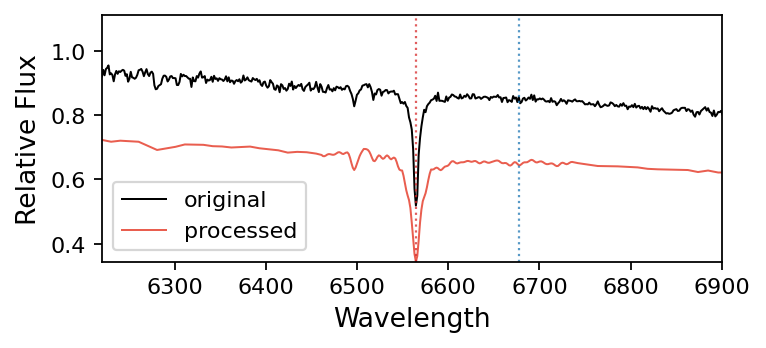

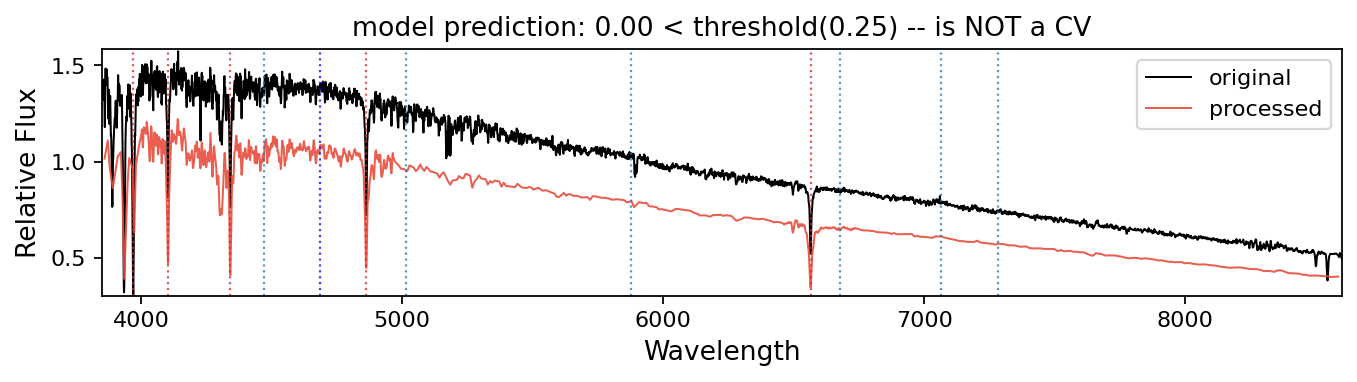

In [8]:
# ******** 联合预测 ********
obsid = 264301072

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

预测结果（1=污染，0=目标）:
[1]
[0.] [1]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/485207236',
 './DR11LRS_485207236.fits.gz')

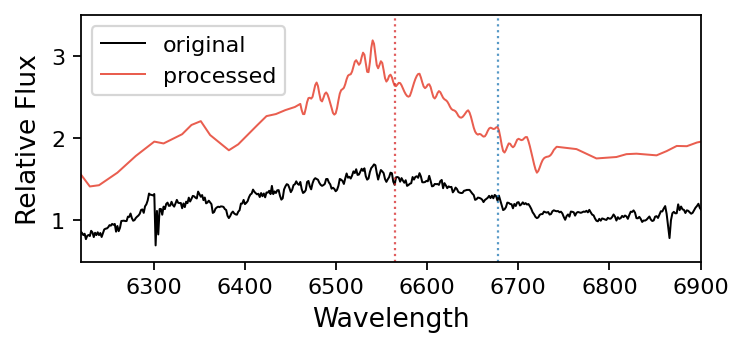

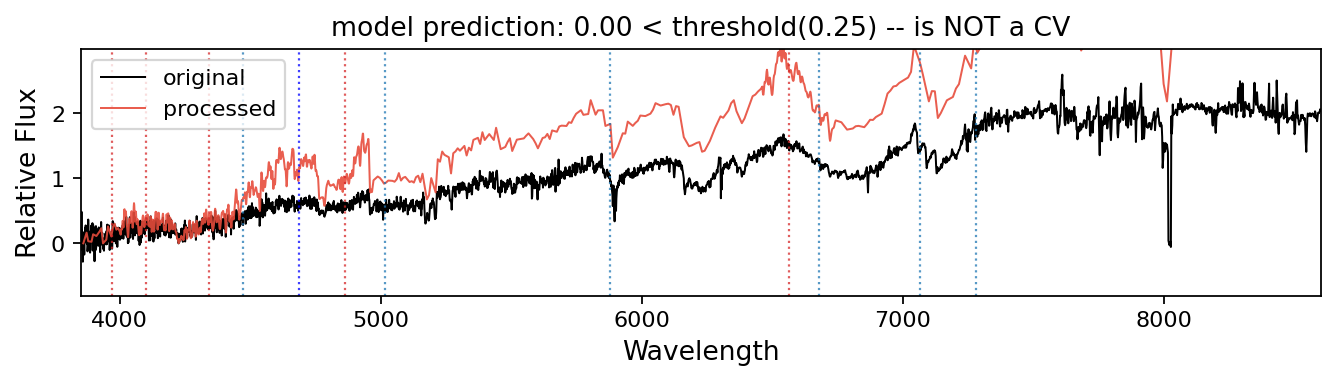

In [9]:
# ******** 联合预测 ********
obsid = 485207236

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

./DR11LRS_677502003.fits.gz already exists.
预测结果（1=污染，0=目标）:
[1]
[0.] [1]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/677502003',
 './DR11LRS_677502003.fits.gz')

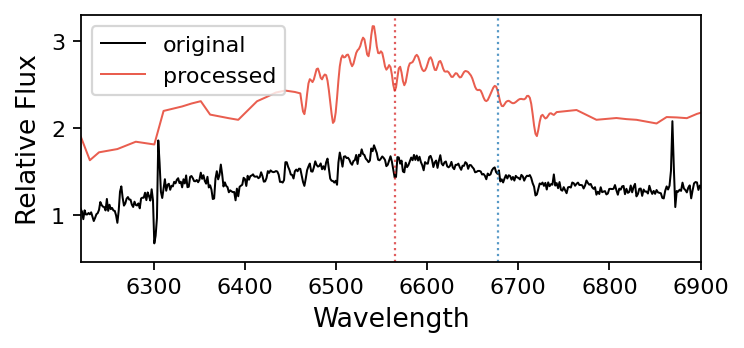

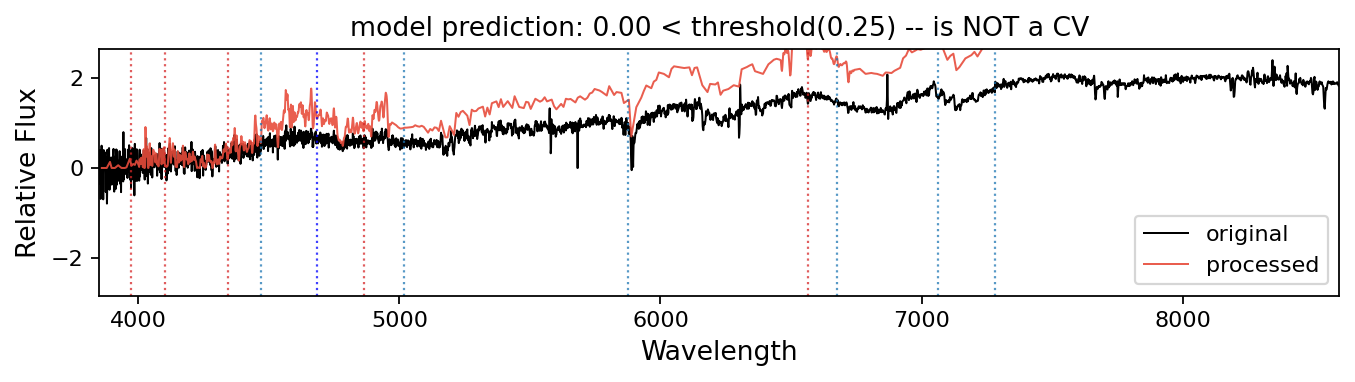

In [7]:
# ******** 联合预测 ********
obsid = 677502003

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

./DR11LRS_420911117.fits.gz already exists.
预测结果（1=污染，0=目标）:
[1]
[0.00131676] [1]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/420911117',
 './DR11LRS_420911117.fits.gz')

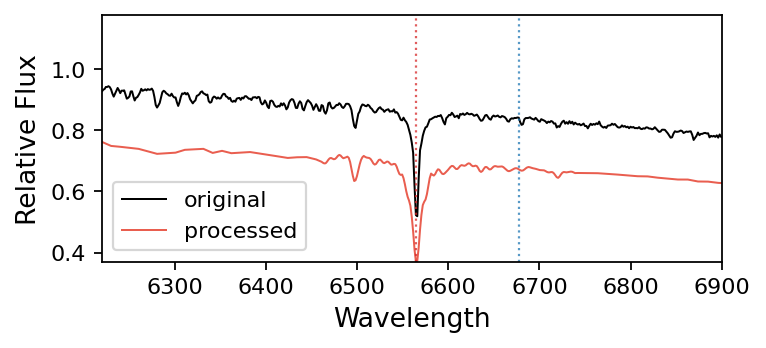

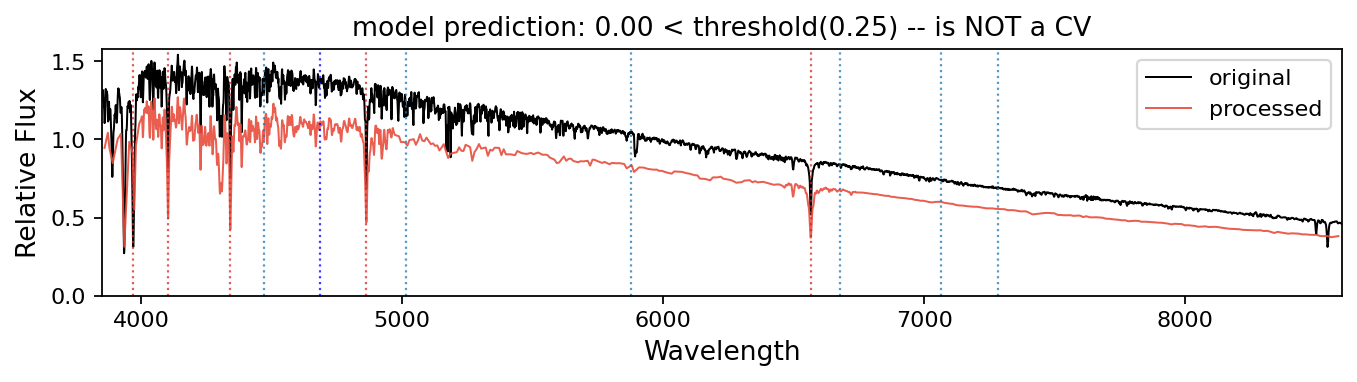

In [8]:
# ******** 联合预测 ********
obsid = 420911117

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

./DR11LRS_483901014.fits.gz already exists.
预测结果（1=污染，0=目标）:
[0]
[0.84987836] [0]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/483901014',
 './DR11LRS_483901014.fits.gz')

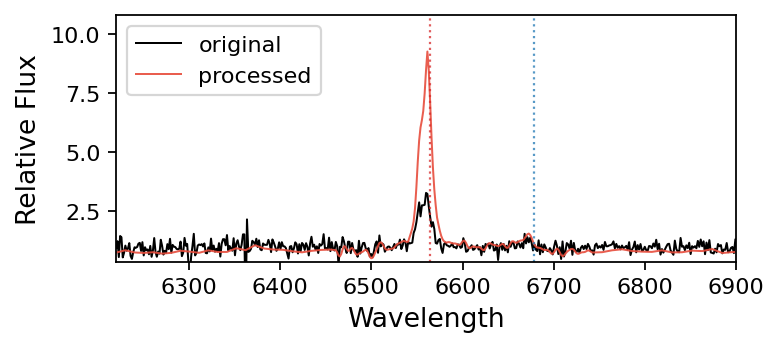

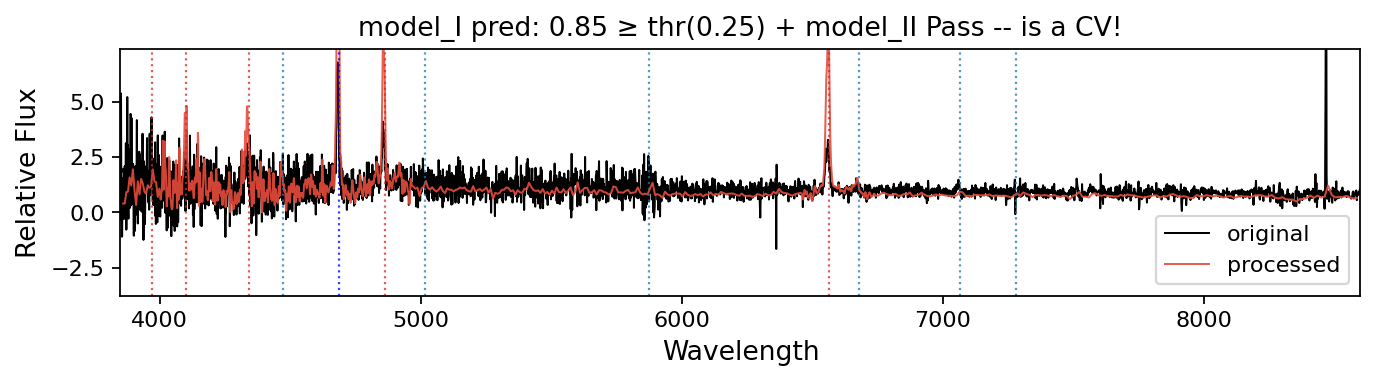

In [9]:
# ******** 联合预测 ********
obsid = 483901014

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

预测结果（1=污染，0=目标）:
[1]
[0.] [1]


('http://www.lamost.org/dr11/v1.0/spectrum/fits/617804083',
 './DR11LRS_617804083.fits.gz')

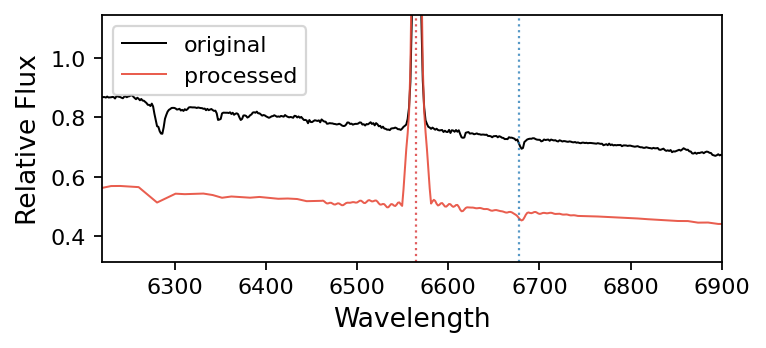

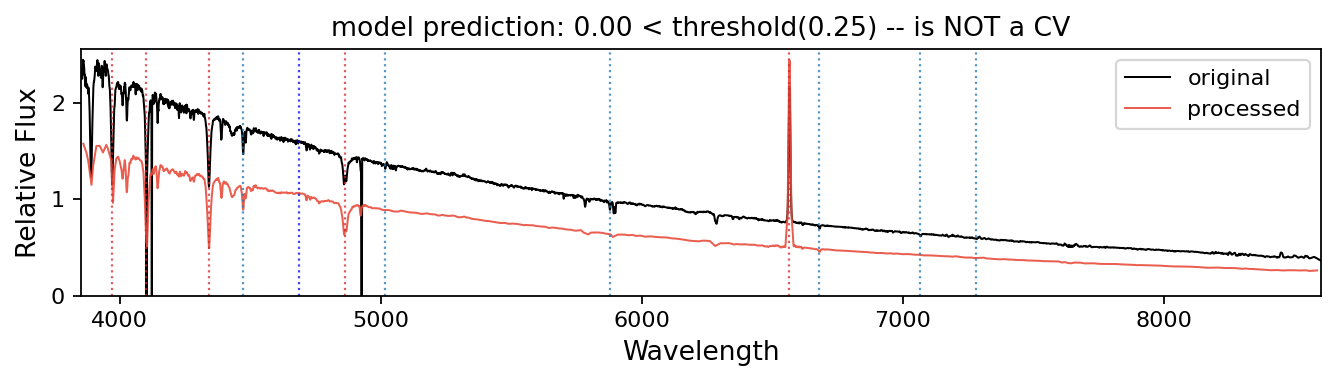

In [10]:
# ******** 联合预测 ********
obsid = 617804083

url, fitsfile = download_lamost_DR11(obsid, path='./') #下载光谱到指定目录
w,f = read_sp(fitsfile)
fluxf = process_sp(w,f)
predictions = predict_new_data(np.array([fluxf]))
predictions2 = predict_new_data_contamination(np.array([fluxf]))
print(predictions, predictions2)
plot_and_predict()

url, fitsfile

正在读取: J0933_2.fits
原始范围: [3600.00, 9824.00]
截断范围: [3800.00, 8499.20] (Safe Range: 3800-9000)
点数变化: 7781 -> 5875
正在调用 process_sp ...
正在预测 ...
预测结果（1=污染，0=目标）:
[0]

✅ 预测成功！
结果 (Predictions): [0.98982192]
污染 (Contamination): [0]


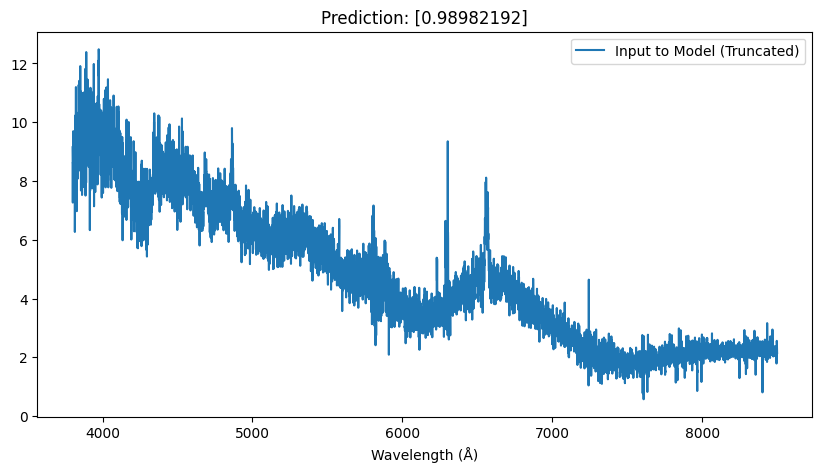

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. 读取函数
def load_fits_spectrum(file_path):
    with fits.open(file_path) as hdul:
        data = hdul[1].data
        wavelength = data['WAVELENGTH']
        flux = data['FLUX']
    return wavelength, flux

# 2. 主逻辑
local_file = 'J0933_2.fits'
print(f"正在读取: {local_file}")
w_loc, f_loc = load_fits_spectrum(local_file)

if w_loc is not None:
    # ================= 核心修复部分 =================
    # 1. 排序 (防止波长乱序导致插值错误)
    sort_idx = np.argsort(w_loc)
    w_sorted = w_loc[sort_idx]
    f_sorted = f_loc[sort_idx]
    
    # 2. 激进截断 (Aggressive Truncation)
    # 标准数据大约是 3700-9100。
    # 我们为了避开 IndexError，强制截断到 [3800, 9000]。
    # 只要保留了核心特征，不会严重影响分类预测。
    safe_min = 3800.0
    safe_max = 8500.0
    
    mask = (w_sorted >= safe_min) & (w_sorted <= safe_max)
    w_fixed = w_sorted[mask]
    f_fixed = f_sorted[mask]
    
    print(f"原始范围: [{np.min(w_loc):.2f}, {np.max(w_loc):.2f}]")
    print(f"截断范围: [{np.min(w_fixed):.2f}, {np.max(w_fixed):.2f}] (Safe Range: 3800-9000)")
    print(f"点数变化: {len(w_loc)} -> {len(w_fixed)}")

    try:
        # 3. 再次尝试预处理
        print("正在调用 process_sp ...")
        fluxf_loc = process_sp(w_fixed, f_fixed)
        
        # 4. 构造输入并预测
        input_data = np.array([fluxf_loc])
        
        print("正在预测 ...")
        pred1 = predict_new_data(input_data)
        pred2 = predict_new_data_contamination(input_data)
        
        print("\n" + "="*30)
        print(f"✅ 预测成功！")
        print(f"结果 (Predictions): {pred1}")
        print(f"污染 (Contamination): {pred2}")
        print("="*30)
        
        # 5. 绘图确认
        plt.figure(figsize=(10, 5))
        plt.plot(w_fixed, f_fixed, label='Input to Model (Truncated)')
        plt.title(f"Prediction: {pred1}")
        plt.xlabel("Wavelength (Å)")
        plt.legend()
        plt.show()
        
    except IndexError as e:
        print(f"\n❌ 依然报错 (IndexError): {e}")
        print("如果还是报错 1458 out of bounds，请尝试将 safe_max 进一步调小到 8900。")
    except Exception as e:
        print(f"\n❌ 其他错误: {e}")
else:
    print("文件读取失败")

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings

# 忽略除零等警告
warnings.filterwarnings('ignore')

# ================= 配置 =================
INPUT_FOLDER = 'SDSS_Spectra_Downloads'  # 你的 fits 文件夹
OUTPUT_CSV = 'Prediction_Results.csv'    # 结果保存文件名

# ================= 1. 定义读取函数 =================
def load_sdss_spectrum(file_path):
    try:
        with fits.open(file_path) as hdul:
            data = hdul[1].data
            cols = data.columns.names
            
            # 处理波长 (SDSS通常是loglam)
            if 'loglam' in cols:
                w = 10 ** data['loglam']
            elif 'WAVELENGTH' in cols:
                w = data['WAVELENGTH']
            elif 'WAVE' in cols:
                w = data['WAVE']
            else:
                return None, None
            
            f = data['flux'] if 'flux' in cols else data['FLUX']
            
        return w, f
    except Exception:
        return None, None

# ================= 2. 关键修复：强制模拟 LAMOST 分辨率 =================
def force_lamost_resolution(w, f):
    """
    将任意光谱强制重采样为 LAMOST 格式：
    范围: 3700 - 9000 Å
    点数: 3900 个 (降低分辨率，防止点数过多导致索引溢出)
    """
    # 1. 清洗无效值
    mask = np.isfinite(w) & np.isfinite(f)
    w = w[mask]
    f = f[mask]
    
    if len(w) == 0:
        return None, None
    
    # 2. 排序
    sort_idx = np.argsort(w)
    w = w[sort_idx]
    f = f[sort_idx]
    
    # 3. [核心步骤] 创建标准目标网格
    # 这完全模仿了成功的 LAMOST 数据的结构
    # 必须使用 np.linspace 强制指定点数为 3900 左右
    target_w = np.linspace(3700, 9000, 3900)
    
    # 4. 插值 (Downsampling)
    # 将原本密集的 6000+ 个点，缩减映射到 3900 个点上
    target_f = np.interp(target_w, w, f)
    
    return target_w, target_f

# ================= 3. 批量处理 =================
def main():
    if not os.path.exists(INPUT_FOLDER):
        print(f"错误: 文件夹 {INPUT_FOLDER} 不存在")
        return

    file_list = [f for f in os.listdir(INPUT_FOLDER) if f.endswith('.fits') or f.endswith('.gz')]
    total_files = len(file_list)
    print(f"📂 找到 {total_files} 个文件，开始处理...\n")
    
    results = []

    for i, filename in enumerate(file_list):
        filepath = os.path.join(INPUT_FOLDER, filename)
        print(f"[{i+1}/{total_files}] {filename} ... ", end="")
        
        # 1. 读取
        w, f = load_sdss_spectrum(filepath)
        
        if w is None:
            print("❌ 读取失败 (跳过)")
            continue
            
        # 2. 强制降低分辨率 (解决 index error 的关键)
        w_lamost, f_lamost = force_lamost_resolution(w, f)
        
        if w_lamost is None:
            print("❌ 数据无效 (跳过)")
            continue

        try:
            # 3. 预测
            # 现在的 w_lamost 长度固定是 3900，绝不会报错了
            fluxf = process_sp(w_lamost, f_lamost)
            
            input_data = np.array([fluxf])
            
            # 获取预测结果
            pred_class = predict_new_data(input_data)
            pred_contam = predict_new_data_contamination(input_data)
            
            # 提取数值
            p_cls = pred_class[0] if len(pred_class) > 0 else "N/A"
            p_con = pred_contam[0] if len(pred_contam) > 0 else "N/A"
            
            print(f"✅ 预测: {p_cls} | 污染: {p_con}")
            
            results.append({
                'Filename': filename,
                'Prediction': p_cls,
                'Contamination': p_con
            })
            
        except IndexError:
            # 万一还是报错，尝试更极端的截断
            print("⚠️ 依然溢出，尝试二次重试...", end="")
            try:
                # 进一步减少范围和点数
                w_retry = np.linspace(3800, 8500, 3500)
                f_retry = np.interp(w_retry, w, f)
                fluxf = process_sp(w_retry, f_retry)
                input_data = np.array([fluxf])
                p_cls = predict_new_data(input_data)[0]
                print(f"✅ 重试成功: {p_cls}")
                results.append({'Filename': filename, 'Prediction': p_cls, 'Contamination': 'Retry', 'Status': 'OK'})
            except Exception as e:
                print(f"❌ 最终失败: {e}")
        except Exception as e:
            print(f"❌ 错误: {e}")

    # ================= 4. 保存结果 =================
    if results:
        df_res = pd.DataFrame(results)
        df_res.to_csv(OUTPUT_CSV, index=False)
        print("\n" + "="*30)
        print(f"🎉 处理完成，结果已保存至: {OUTPUT_CSV}")
        print("="*30)
        print(df_res.head())

if __name__ == "__main__":
    main()

📂 找到 121 个文件，开始处理...

[1/121] 1RXS_J161935.7+524630_spec-3442-54983-0276.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[2/121] 1RXS_J161935.7+524630_spec-8062-58251-0766.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 0.9983077605939518
[3/121] 2RXS_J153818.6+512347_spec-6722-56431-0820.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[4/121] 2RXS_J153818.6+512347_spec-796-52401-0388.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[5/121] 2RXS_J153818.6+512347_spec-8407-57839-0736.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[6/121] 2XMM_J131223.4+173659_spec-5424-56033-0750.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[7/121] AI_Tri_spec-7737-57722-0164.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[8/121] AN_UMa_spec-1436-53054-0057.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[9/121] AN_UMa_spec-6649-56364-0388.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 1.0
[10/121] AP_CrB_spec-1654-53498-0542.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 0.995
[11/121] AP_CrB_spec-2459-54339-0533.fits ... ⚠️ 依然溢出，尝试二次重试...✅ 重试成功: 0.99
[12/121] AP_CrB_spec-2459-54544-0521.fits ... ⚠️ 依然溢出，尝